
# Logistic Regression – End-to-End Live Demo Notebook


This notebook covers Logistic Regression concepts step-by-step with theory, math intuition, visualizations,
and hands-on Python implementation (Binary + Multiclass).

---
## Agenda
1. Linear vs Logistic Regression  
2. Sigmoid Function & Intuition  
3. Cost Function – Cross Entropy  
4. Gradient Descent for Logistic Regression  
5. Decision Boundary Visualization  
6. Overfitting & Regularization (L1 & L2)  
7. Binary Classification – From Scratch  
8. Multiclass Classification – One-vs-Rest  
9. Model Interpretation  

---



## 1. Linear Regression vs Logistic Regression

| Aspect | Linear Regression | Logistic Regression |
|------|------------------|---------------------|
| Output | Continuous | Discrete (0 / 1) |
| Task | Regression | Classification |
| Function | Linear | Sigmoid(Logit) |
| Cost | MSE | Cross-Entropy |

Logistic Regression models **probability of class = 1**.



## 2. Sigmoid (Logistic) Function

The sigmoid maps any real value to **(0,1)**

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

Used to represent probability.


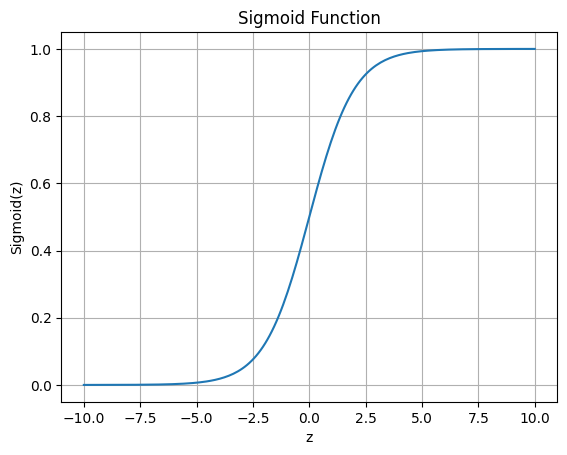

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
plt.plot(z, sigmoid(z))
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid()
plt.show()



### Derivative of Sigmoid

\[
\sigma'(z) = \sigma(z)(1 - \sigma(z))
\]

Important for **Gradient Descent**


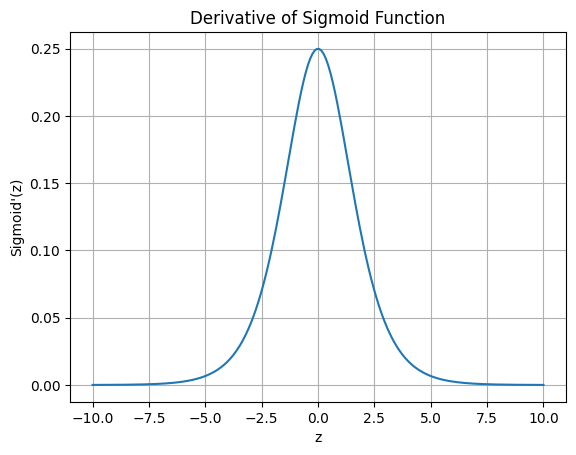

In [ ]:

sig = sigmoid(z)
plt.plot(z, sig * (1 - sig))
plt.title("Derivative of Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Sigmoid'(z)")
plt.grid()
plt.show()



## 3. Why Not MSE? Why Cross-Entropy?

- MSE leads to **non-convex loss**
- Cross-Entropy provides **convex loss**
- Ensures faster & stable convergence

### Cross-Entropy Loss

For single sample:
\[
Loss = -[y \log(h(x)) + (1-y) \log(1-h(x))]
\]



## 4. Logistic Regression from Scratch (Binary Classification)


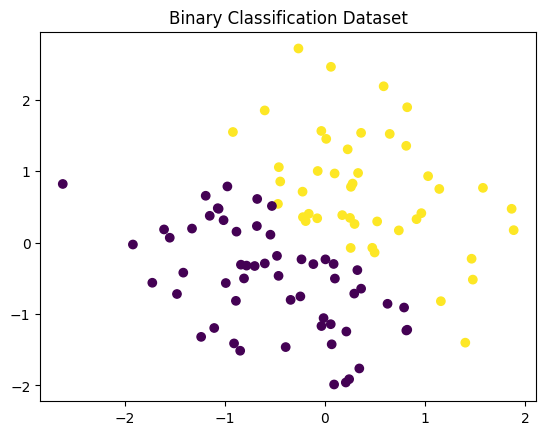

In [ ]:

# Generate simple dataset
np.random.seed(42)
X = np.random.randn(100, 2)
y = (X[:,0] + X[:,1] > 0).astype(int)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Binary Classification Dataset")
plt.show()


In [ ]:

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Initialize weights
theta = np.zeros(X_b.shape[1])
lr = 0.1
epochs = 1000


In [ ]:

# Gradient Descent
losses = []

for _ in range(epochs):
    z = X_b @ theta
    h = sigmoid(z)

    # Cross-Entropy Loss
    loss = -np.mean(y*np.log(h+1e-9) + (1-y)*np.log(1-h+1e-9))
    losses.append(loss)

    gradient = X_b.T @ (h - y) / len(y)
    theta -= lr * gradient


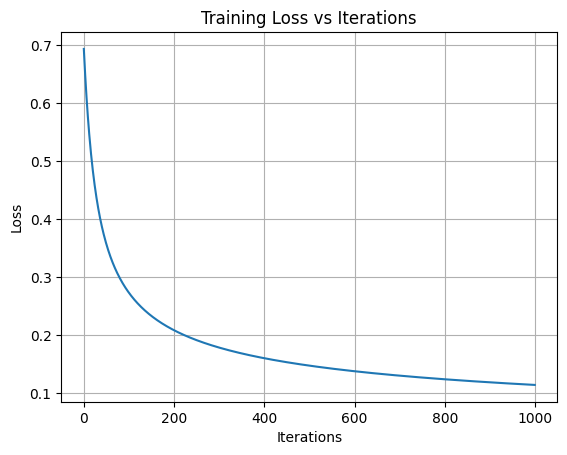

In [ ]:

plt.plot(losses)
plt.title("Training Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid()
plt.show()



## 5. Decision Boundary Visualization


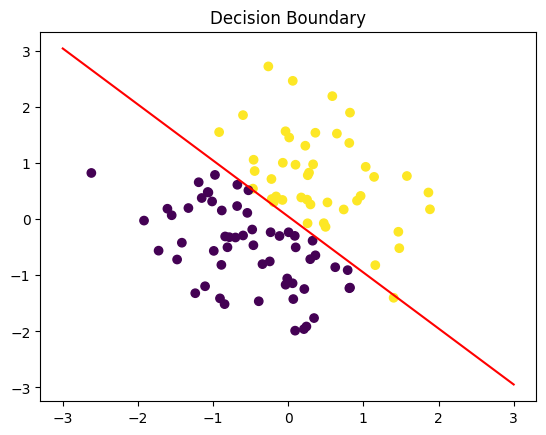

In [ ]:

x1 = np.linspace(-3, 3, 100)
x2 = -(theta[0] + theta[1]*x1) / theta[2]

plt.scatter(X[:,0], X[:,1], c=y)
plt.plot(x1, x2, 'r')
plt.title("Decision Boundary")
plt.show()



## 6. Overfitting & Regularization

### L2 Regularization (Ridge)
\[
Loss = CE + \lambda \sum \theta^2
\]

### L1 Regularization (Lasso)
\[
Loss = CE + \lambda \sum |\theta|
\]



## 7. Logistic Regression using Scikit-Learn


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0



## 8. Multiclass Logistic Regression (One-vs-Rest)


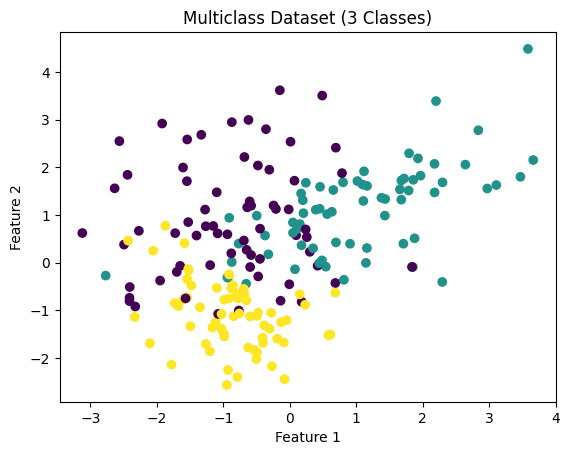

In [ ]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

X_mc, y_mc = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42
)

plt.scatter(X_mc[:, 0], X_mc[:, 1], c=y_mc, cmap="viridis")
plt.title("Multiclass Dataset (3 Classes)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [ ]:

model_mc = LogisticRegression(multi_class='ovr')
model_mc.fit(X_mc, y_mc)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr')


## 9. Interpretation

- Coefficients show **feature influence**
- Positive weight → increases probability of class = 1
- Negative weight → decreases probability



